# Fig 3 — Naive vs aligned trace at offset = 20s (split into two figures)

Emits TWO independent PDFs:
  - fig3a_trace_naive.pdf  — E2 naive run; playhead jumps to live edge.
  - fig3b_trace_aligned.pdf — E3 aligned run; playhead continues smoothly.
Each is a 1-column figure ~1.7 in tall; placed independently in the paper.

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "figures"))

import matplotlib.pyplot as plt
import numpy as np

from _data import find_median_run_dir, load_run_metrics
from _style import (
    COL_ALIGNED,
    COL_NAIVE,
    COLUMN_WIDTH_IN,
    apply_acm_style,
)

apply_acm_style()

In [2]:
FILTER_DELAY_S = 20
PANEL_X_MAX = 60
PANEL_Y_MAX = 60

naive_run = find_median_run_dir("e2", "naive_offset20", "max_playhead_gap_ms")
aligned_run = find_median_run_dir("e3", "aligned_offset20", "max_playhead_gap_ms")

naive_metrics = load_run_metrics(naive_run)
aligned_metrics = load_run_metrics(aligned_run)
naive_switches = json.loads((naive_run / "switch_records.json").read_text())
aligned_switches = json.loads((aligned_run / "switch_records.json").read_text())


def find_buffer_end_column(metrics):
    """Look for a buffer-end series under a few common column names.
    Returns None if the metrics dataframe does not carry one."""
    for candidate in ("buffer_end_s", "buffer_end_time", "buffer_end_pts",
                      "buffered_end", "bufferEnd"):
        if candidate in metrics.columns:
            return candidate
    return None


def plot_panel(ax, metrics, switches, primary_color, title,
               filter_delay_s, x_max, y_max):
    """Show video playback position against real time, with switch
    events marked and a reference line for continuous playback."""

    wall = metrics["wall_clock_s"].to_numpy()
    playhead = metrics["current_time"].to_numpy()

    # Reference diagonal: where the playhead would sit under continuous
    # 1x playback, offset by the filter delay.
    ideal_x = np.array([0.0, float(x_max)])
    ideal_y = np.clip(ideal_x - filter_delay_s, 0.0, None)
    ax.plot(ideal_x, ideal_y,
            color="gray", linestyle=":", linewidth=0.9, alpha=0.75,
            label="Ideal playback (no disruption)")

    # Actual playhead position over time.
    ax.plot(wall, playhead,
            color=primary_color, linewidth=1.5,
            label="Actual playback")

    # Dashed overlay for the latest downloaded frame, if available.
    buf_col = find_buffer_end_column(metrics)
    if buf_col is not None:
        ax.plot(wall, metrics[buf_col].to_numpy(),
                color=primary_color, linestyle="--",
                linewidth=1.0, alpha=0.8,
                label="Latest downloaded")

    # Each switch: a tick mark on the x-axis plus the jump magnitude.
    for s in [r for r in switches if r.get("eventType") == "switch"]:
        sent_s = s["switchSentAt"] / 1000.0
        ax.axvline(sent_s, color="black", linestyle=":",
                   linewidth=0.6, alpha=0.45)
        jump_s = s.get("playheadGapMs", 0) / 1000.0
        ax.annotate(
            f"{jump_s:+.1f} s",
            xy=(sent_s, y_max * 0.93),
            xytext=(0, 0), textcoords="offset points",
            fontsize=6, va="top", ha="center", color="black",
        )

    ax.set_xlabel("Real time (s)")
    ax.set_ylabel("Position in video (s)")
    ax.set_title(title, loc="left", fontsize=8, pad=2)
    ax.set_xlim(0, x_max)
    ax.set_ylim(0, y_max)
    n_entries = 3 if buf_col is not None else 2
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22),
              ncol=n_entries, fontsize=6, frameon=False,
              columnspacing=1.4, handlelength=2.2)

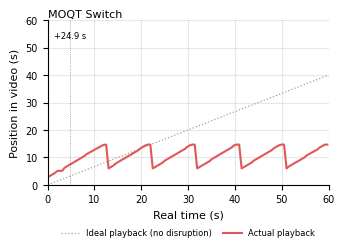

In [3]:
fig_a, ax_a = plt.subplots(figsize=(COLUMN_WIDTH_IN, 2.4),
                            constrained_layout=True)
plot_panel(ax_a, naive_metrics, naive_switches, COL_NAIVE,
           "MOQT Switch",
           FILTER_DELAY_S, PANEL_X_MAX, PANEL_Y_MAX)
fig_a.savefig(Path.cwd().parent / "figures" / "fig3a_trace_naive.pdf")
fig_a.savefig(Path.cwd().parent / "figures" / "fig3a_trace_naive.png", dpi=200)

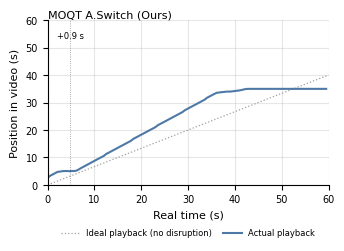

In [4]:
fig_b, ax_b = plt.subplots(figsize=(COLUMN_WIDTH_IN, 2.4),
                            constrained_layout=True)
plot_panel(ax_b, aligned_metrics, aligned_switches, COL_ALIGNED,
           "MOQT A.Switch (Ours)",
           FILTER_DELAY_S, PANEL_X_MAX, PANEL_Y_MAX)
fig_b.savefig(Path.cwd().parent / "figures" / "fig3b_trace_aligned.pdf")
fig_b.savefig(Path.cwd().parent / "figures" / "fig3b_trace_aligned.png", dpi=200)